# Concordance with bulk methylomes (Fig S7)

Part of the **[Fig. 1 chapter](fig1.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `'/home/zhoujt/software/wgbs_tools/references/hg38/CpG.bed.gz'`  ·  _ref: CpG_
- `'/large_experiments/zhoulab/ref/hg38/fasta/hg38.fa'`  ·  _reference_
- `f'{indir}subtype_meta.tsv'`  ·  _metadata_
- `f'{bulk_dir}Loyfer2023_1kb.mcds'`  ·  _mC matrix (mcds)_
- `f'{bulk_dir}Loyfer2023_1kb.hdf'`  ·  _ext: Loyfer_
- `f'{bulk_dir}cosine_Loyfer2023.hdf'`  ·  _ext: Loyfer_
- `f'{indir}merged_allc/subtype1k.mcds'`  ·  _sc/pseudobulk mC (allc)_
- `f'{outdir}cosine_subtype_Loyfer.hdf'`  ·  _ext: Loyfer_
- `f'{bulk_dir}Schultz2015_1kb.mcds'`  ·  _mC matrix (mcds)_
- `f'{bulk_dir}Schultz2015_1kb.hdf'`  ·  _ext: Schultz_
- `f'{bulk_dir}cosine_Schultz2015.hdf'`  ·  _ext: Schultz_
- `f'{bulk_dir}Schultz2015_1kb_hg38.hdf'`  ·  _ext: Schultz_
- `f'{bulk_dir}cosine_L2any_Schultz.hdf'`  ·  _ext: Schultz_
- `f'{outdir}cosine_subtype_Schultz.hdf'`  ·  _ext: Schultz_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import numpy as np
import pandas as pd
from glob import glob


In [3]:
ref = pd.read_csv('/home/zhoujt/software/wgbs_tools/references/hg38/CpG.bed.gz', sep='\t', header=None, index_col=2)

from pyfaidx import Fasta
f = Fasta('/large_experiments/zhoulab/ref/hg38/fasta/hg38.fa')
seq = {}
for chrom in ref[0].unique():
    seq[chrom] = f[chrom][:].seq.upper()
    print(chrom)

ref['seq'] = [seq[xx][(yy-1):(yy+2)] for xx,yy in zip(ref[0].values, ref[1].values)]
ref.to_hdf('hg38.CpG.3bp.hdf', key='data')


In [4]:
from glob import glob 
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib import cm as cm
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

from ALLCools.clustering import *
from ALLCools.plot import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.mcds import MCDS

from scipy.stats import pearsonr
from sklearn.metrics import pairwise_distances
import seaborn as sns
import h5py
import time
from concurrent.futures import ProcessPoolExecutor, as_completed

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [5]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/compare_bulkmc/'


In [6]:
L2_meta = pd.read_csv(f'{indir}subtype_meta.tsv', header=0, index_col=0, sep='\t')
L2_annot = L2_meta['celltype_L2_both_abbr'].to_dict()

## Loyfer2023

In [7]:
bulk_dir = f'{ENTEX_ROOT}/bulk_mC/Loyfer2023/'


In [8]:
mcds = MCDS.open(f'{bulk_dir}Loyfer2023_1kb.mcds', var_dim='chrom1k')
mcds

In [9]:
mcds = mcds.assign_coords({'chrom1k_chrom': ('chrom1k', mcds.coords['chrom1k_chrom'].data),
                    'chrom1k_start': ('chrom1k', mcds.coords['chrom1k_start'].data),
                    'chrom1k_end': ('chrom1k', mcds.coords['chrom1k_end'].data),
                   })
mcds

In [10]:
# mcds.add_feature_cov_mean(var_dim='chrom1k', plot=False)
cov = mcds['chrom1k_da'].sel(count_type='cov').mean(dim='cell').squeeze().to_pandas()


In [11]:
mcds = mcds.sel({'chrom1k':cov.index[cov>20]})

In [12]:
black_list_path = '/large_experiments/zhoulab/ref/blacklist/hg38-blacklist.v2.bed.gz'
mcds = mcds.remove_black_list_region(
    black_list_path=black_list_path, f=0.5
)

exclude_chromosome = ['chrX', 'chrY', 'chrM', 'chrL']
mcds = mcds.remove_chromosome(exclude_chromosome)

In [13]:
data = mcds['chrom1k_da_frac'].to_pandas()


In [14]:
data.to_hdf(f'{bulk_dir}Loyfer2023_1kb.hdf', key='data')


In [15]:
data = pd.read_hdf(f'{bulk_dir}Loyfer2023_1kb.hdf', key='data')


In [16]:
from sklearn.metrics import pairwise_distances
dist = pairwise_distances(data, data, 'cosine')
dist = pd.DataFrame(dist, columns=data.index, index=data.index)
# dist.to_hdf(f'{bulk_dir}cosine_Loyfer2023.hdf', key='data')


In [17]:
dist = pd.read_hdf(f'{bulk_dir}cosine_Loyfer2023.hdf', key='data')
cg = sns.clustermap(dist, vmax=0.02, figsize=(20,20), metric='cosine', method='single', xticklabels=2, yticklabels=2)
corder = cg.dendrogram_col.reordered_ind.copy()


In [18]:
mcds_cluster = MCDS.open(f'{indir}merged_allc/subtype1k.mcds', var_dim='chrom1k')
mcds_cluster

In [19]:
# group_meta = pd.read_csv(f'{indir}clustering/merged/group_meta.tsv', sep='\t', header=0, index_col=0)
# mcds_cluster = mcds_cluster.assign_coords(L2_any=('cell', group_meta.loc[mcds_cluster.get_index('cell'), 'L2_any']))
# mcds_cluster = mcds_cluster.groupby('L2_any').sum()
# mcds_cluster = MCDS(mcds_cluster, obs_dim='L2_any', var_dim='chrom1k')
mcds_cluster = mcds_cluster.sel({'mc_type':'CGN'})


In [20]:
cov = mcds_cluster['chrom1k_da'].sel(count_type='cov').mean(dim='cell').squeeze().to_pandas()


In [21]:
mcds_cluster = mcds_cluster.sel({'chrom1k':cov.index[cov>20]})

In [22]:
black_list_path = f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz'
mcds_cluster = mcds_cluster.remove_black_list_region(
    black_list_path=black_list_path, f=0.5
)

exclude_chromosome = ['chrX', 'chrY', 'chrM', 'chrL']
mcds_cluster = mcds_cluster.remove_chromosome(exclude_chromosome)

In [23]:
bulk_dir = f'{ENTEX_ROOT}/bulk_mC/Loyfer2023/'
data_bulk = pd.read_hdf(f'{bulk_dir}Loyfer2023_1kb.hdf', key='data')


In [24]:
selb = mcds_cluster.get_index('chrom1k').intersection(data_bulk.columns)
# selb = mcds_cluster.get_index('chrom1k').intersection(mcds.get_index('chrom1k'))
print(len(selb))

In [25]:
mcds_cluster = mcds_cluster.sel({'chrom1k':selb})
data_cluster = mcds_cluster['chrom1k_da_frac'].to_pandas()

# mcds = mcds.sel({'chrom1k':selb})
# data_bulk = mcds['chrom1k_da_frac'].to_pandas()
data_bulk = data_bulk[selb]


In [26]:
from sklearn.metrics import pairwise_distances
dist = pairwise_distances(data_bulk, data_cluster, 'cosine')
dist = pd.DataFrame(dist, columns=data_cluster.index, index=data_bulk.index)
dist.to_hdf(f'{outdir}cosine_subtype_Loyfer.hdf', key='data')


In [27]:
dist = pd.read_hdf(f'{outdir}cosine_subtype_Loyfer.hdf', key='data').iloc[corder]
dist.columns = dist.columns.map(L2_annot)
bestbulk = np.argmin(dist, axis=0)
bestbulk[dist.min(axis=0)>0.01] = dist.shape[0]
dist = dist.iloc[:, np.argsort(bestbulk)]
# sns.clustermap(dist, vmax=0.015, row_cluster=False, col_cluster=False, cmap='cividis',
#                figsize=(20,20), xticklabels=2, yticklabels=2)


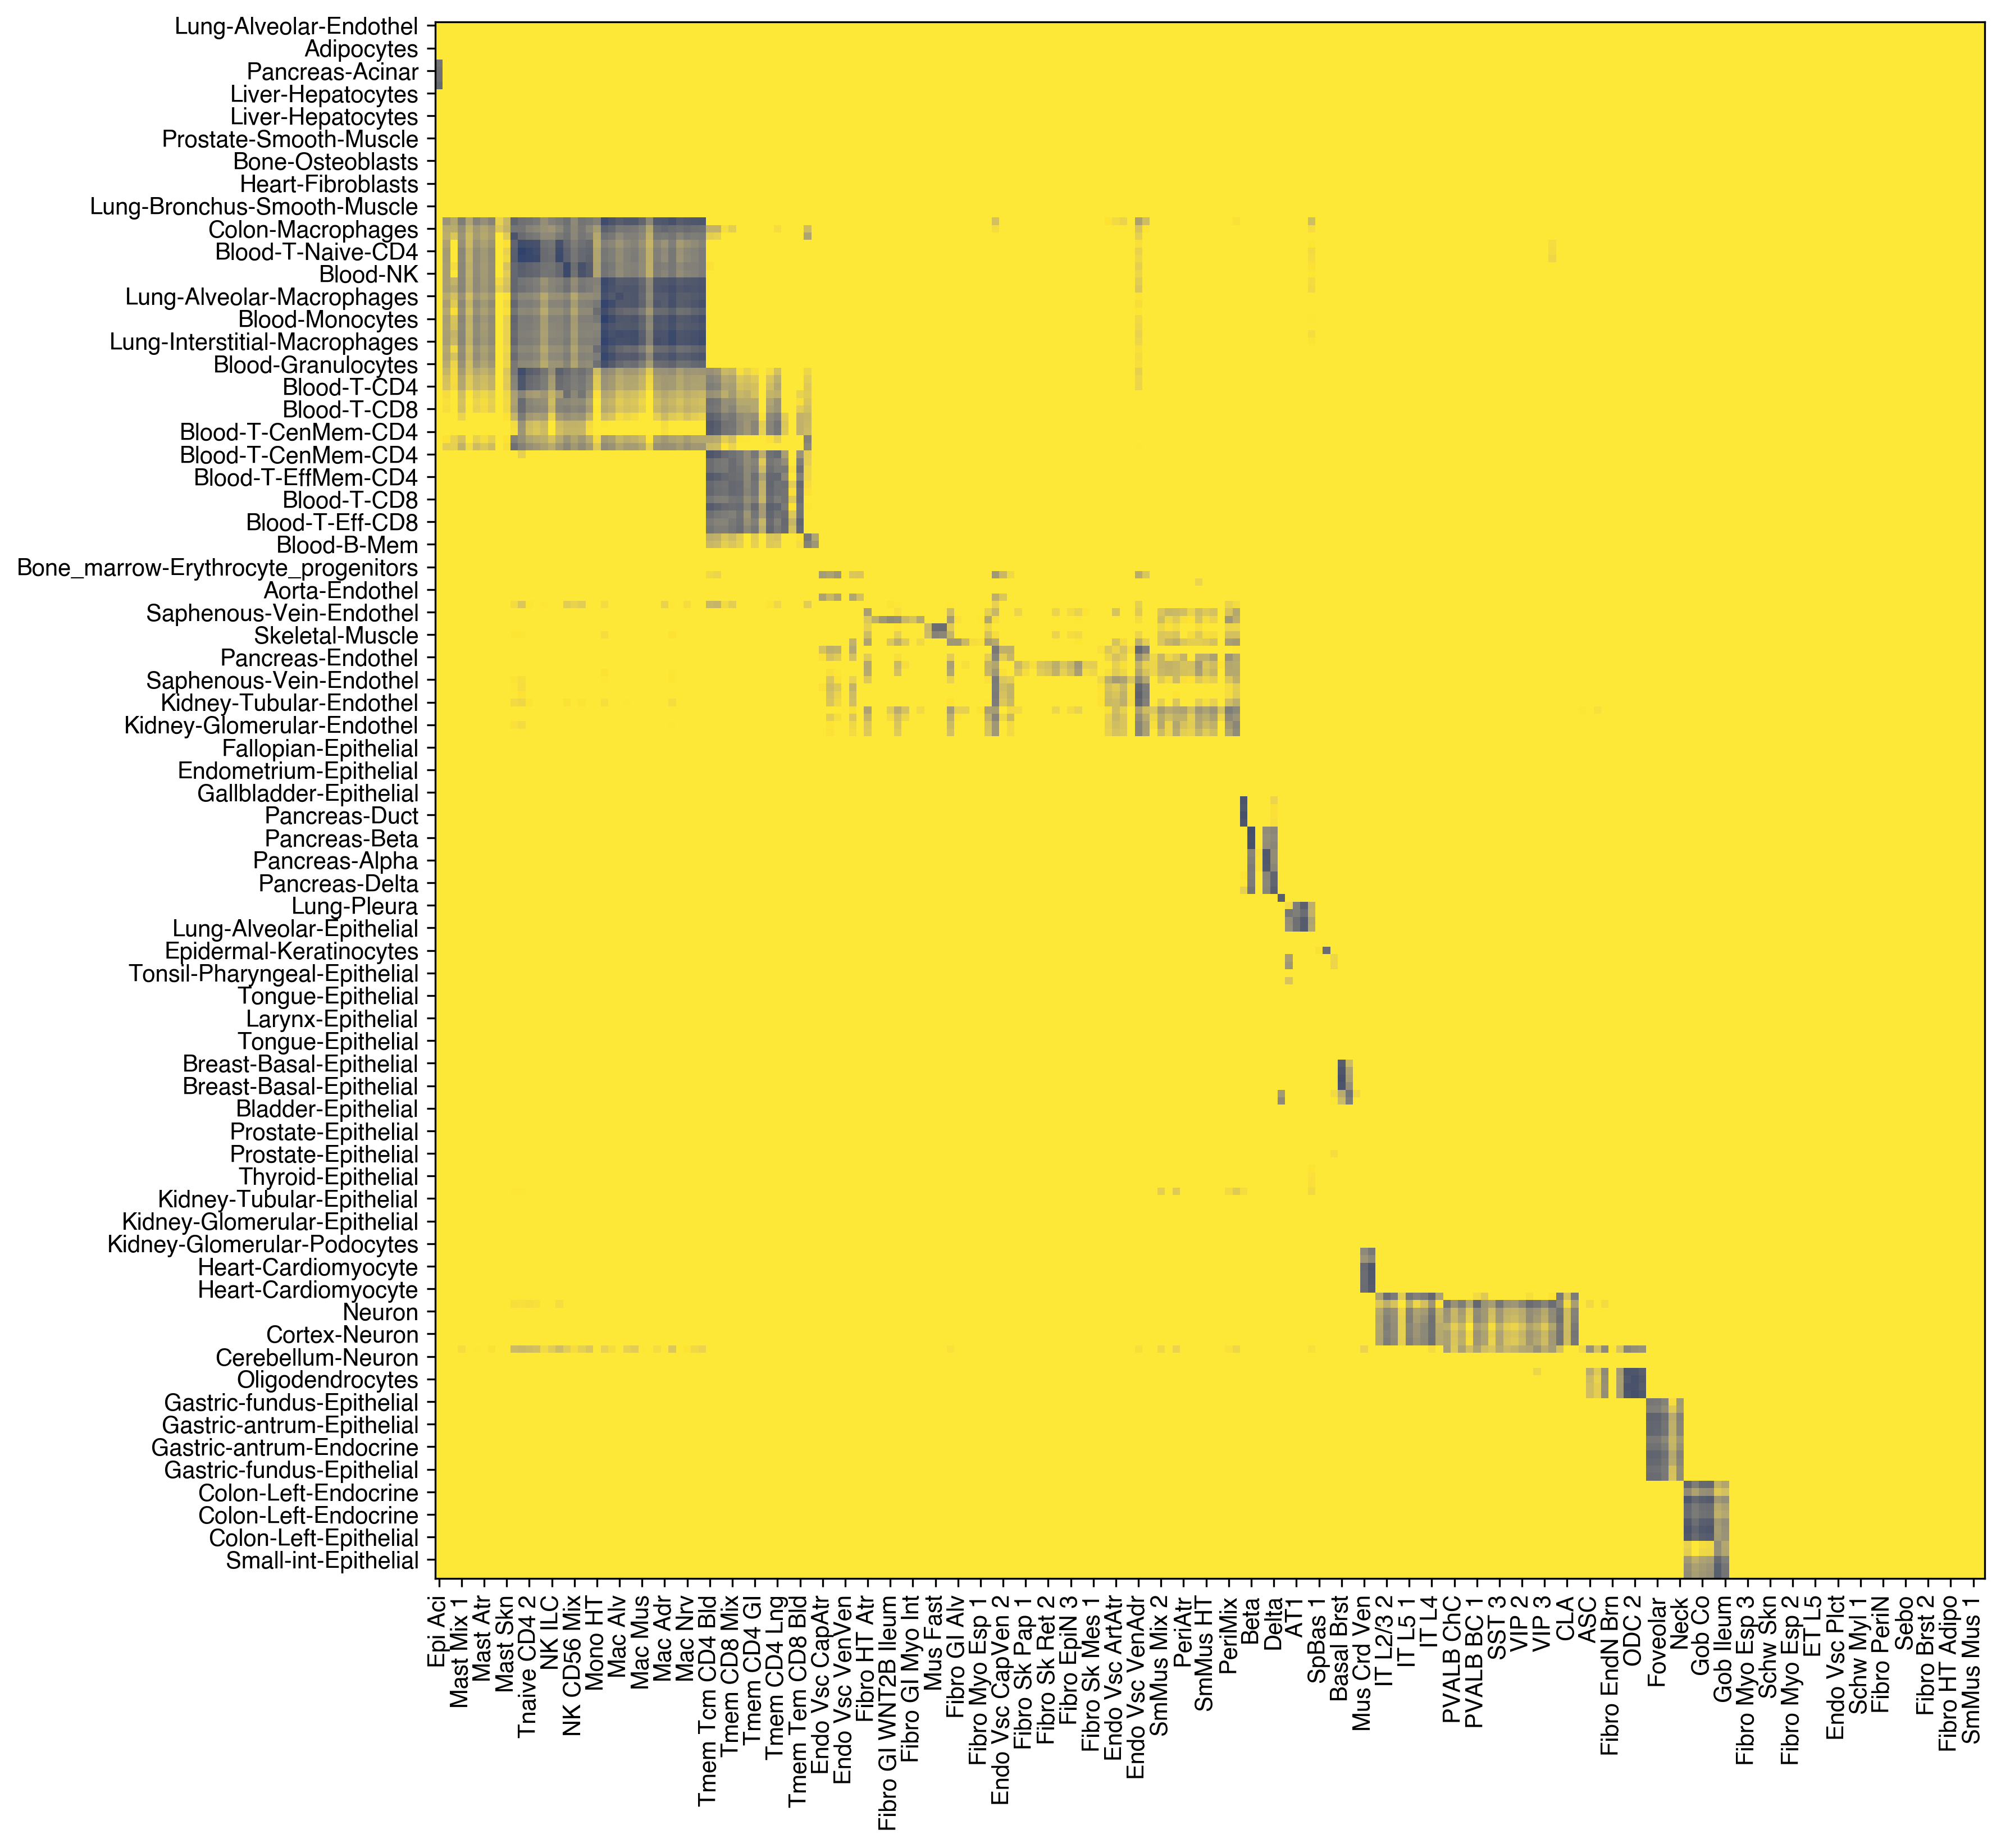

In [28]:
fig, ax = plt.subplots(figsize=(12,12), dpi=300)
ax.imshow(dist, vmin=0, vmax=0.01, cmap='cividis')
xticks = np.arange(0, dist.shape[1], 3)
ax.set_xticks(xticks)
ax.set_xticklabels(dist.columns[xticks], rotation=90)
yticks = np.arange(0, dist.shape[0], 3)
ax.set_yticks(yticks)
ax.set_yticklabels(['-'.join(xx.split('-')[:-1]) for xx in dist.index[yticks]], rotation=0)
fig.savefig(f'{outdir}cosine_subtype_Loyfer.pdf', transparent=True)


## Schultz2015

In [29]:
bulk_dir = f'{ENTEX_ROOT}/bulk_mC/Schultz2015/'


In [30]:
mcds = MCDS.open(f'{bulk_dir}Schultz2015_1kb.mcds', var_dim='chrom1k')
mcds

In [31]:
mcds = mcds.assign_coords({'chrom1k_chrom': ('chrom1k', mcds.coords['chrom1k_chrom'].data),
                    'chrom1k_start': ('chrom1k', mcds.coords['chrom1k_start'].data),
                    'chrom1k_end': ('chrom1k', mcds.coords['chrom1k_end'].data),
                   })
mcds

In [32]:
# mcds.add_feature_cov_mean(var_dim='chrom1k', plot=False)
cov = mcds['chrom1k_da'].sel(count_type='cov').mean(dim='cell').squeeze().to_pandas()


In [33]:
mcds = mcds.sel({'chrom1k':cov.index[cov>20]})

In [34]:
black_list_path = '/large_experiments/zhoulab/ref/blacklist/hg38-blacklist.v2.bed.gz'
mcds = mcds.remove_black_list_region(
    black_list_path=black_list_path, f=0.5
)

exclude_chromosome = ['chrX', 'chrY', 'chrM', 'chrL']
mcds = mcds.remove_chromosome(exclude_chromosome)

In [35]:
data = mcds['chrom1k_da_frac'].to_pandas()


In [36]:
data.to_hdf(f'{bulk_dir}Schultz2015_1kb_hg38.hdf', key='data')


In [37]:
data = pd.read_hdf(f'{bulk_dir}Schultz2015_1kb.hdf', key='data')


In [38]:
from sklearn.metrics import pairwise_distances
dist = pairwise_distances(data, data, 'cosine')
dist = pd.DataFrame(dist, columns=data.index, index=data.index)
dist.to_hdf(f'{bulk_dir}cosine_Schultz2015.hdf', key='data')


In [39]:
dist = pd.read_hdf(f'{bulk_dir}cosine_Schultz2015.hdf', key='data')
cg = sns.clustermap(dist, vmax=0.01, figsize=(10,10), xticklabels=1, yticklabels=1)
corder = cg.dendrogram_col.reordered_ind.copy()


In [40]:
mcds_cluster = MCDS.open(f'{indir}merged_allc/subtype1k.mcds', var_dim='chrom1k')
mcds_cluster

In [41]:
# group_meta = pd.read_csv(f'{indir}clustering/merged/group_meta.tsv', sep='\t', header=0, index_col=0)
# mcds_cluster = mcds_cluster.assign_coords(L2_any=('cell', group_meta.loc[mcds_cluster.get_index('cell'), 'L2_any']))
# mcds_cluster = mcds_cluster.groupby('L2_any').sum()
# mcds_cluster = MCDS(mcds_cluster, obs_dim='L2_any', var_dim='chrom1k')
mcds_cluster = mcds_cluster.sel({'mc_type':'CGN'})


In [42]:
cov = mcds_cluster['chrom1k_da'].sel(count_type='cov').mean(dim='cell').squeeze().to_pandas()


In [43]:
mcds_cluster = mcds_cluster.sel({'chrom1k':cov.index[cov>20]})

In [44]:
black_list_path = f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz'
mcds_cluster = mcds_cluster.remove_black_list_region(
    black_list_path=black_list_path, f=0.5
)

exclude_chromosome = ['chrX', 'chrY', 'chrM', 'chrL']
mcds_cluster = mcds_cluster.remove_chromosome(exclude_chromosome)

In [45]:
bulk_dir = f'{ENTEX_ROOT}/bulk_mC/Schultz2015/'
data_bulk = pd.read_hdf(f'{bulk_dir}Schultz2015_1kb_hg38.hdf', key='data')


In [46]:
selb = mcds_cluster.get_index('chrom1k').intersection(data_bulk.columns)
# selb = mcds_cluster.get_index('chrom1k').intersection(mcds.get_index('chrom1k'))
print(len(selb))

In [47]:
mcds_cluster = mcds_cluster.sel({'chrom1k':selb})
data_cluster = mcds_cluster['chrom1k_da_frac'].to_pandas()

# mcds = mcds.sel({'chrom1k':selb})
# data_bulk = mcds['chrom1k_da_frac'].to_pandas()
data_bulk = data_bulk[selb]


In [48]:
from sklearn.metrics import pairwise_distances
dist = pairwise_distances(data_bulk, data_cluster, 'cosine')
dist = pd.DataFrame(dist, columns=data_cluster.index, index=data_bulk.index)
dist.to_hdf(f'{outdir}cosine_subtype_Schultz.hdf', key='data')


In [49]:
dist = pd.read_hdf(f'{outdir}cosine_subtype_Schultz.hdf', key='data').iloc[corder]
dist.columns = dist.columns.map(L2_annot)
bestbulk = np.argmin(dist, axis=0)
bestbulk[dist.min(axis=0)>0.01] = dist.shape[0]
dist = dist.iloc[:, np.argsort(bestbulk)]
# bestbulk = np.argsort(np.arange(dist.shape[0])[None,:].dot(1-dist)[0])
# dist = dist.iloc[:, bestbulk]


In [50]:
abbr_to_tissue = {
    "TH": "Thymus",
    "LG": "Lung",
    "RA": "Right atrium",
    "RV": "Right ventricle",
    "LV": "Left ventricle",
    "AO": "Aorta",
    "EG": "Oesophagus",
    "GA": "Gastric",
    "AD": "Adrenal gland",
    "PA": "Pancreas",
    "SX": "Spleen",
    "SB": "Small bowel",
    "SG": "Sigmoid colon",
    "FT": "Fat",
    "BL": "Bladder",
    "PO": "Psoas muscle",
    "OV": "Ovary",
    "LI": "Liver"
}


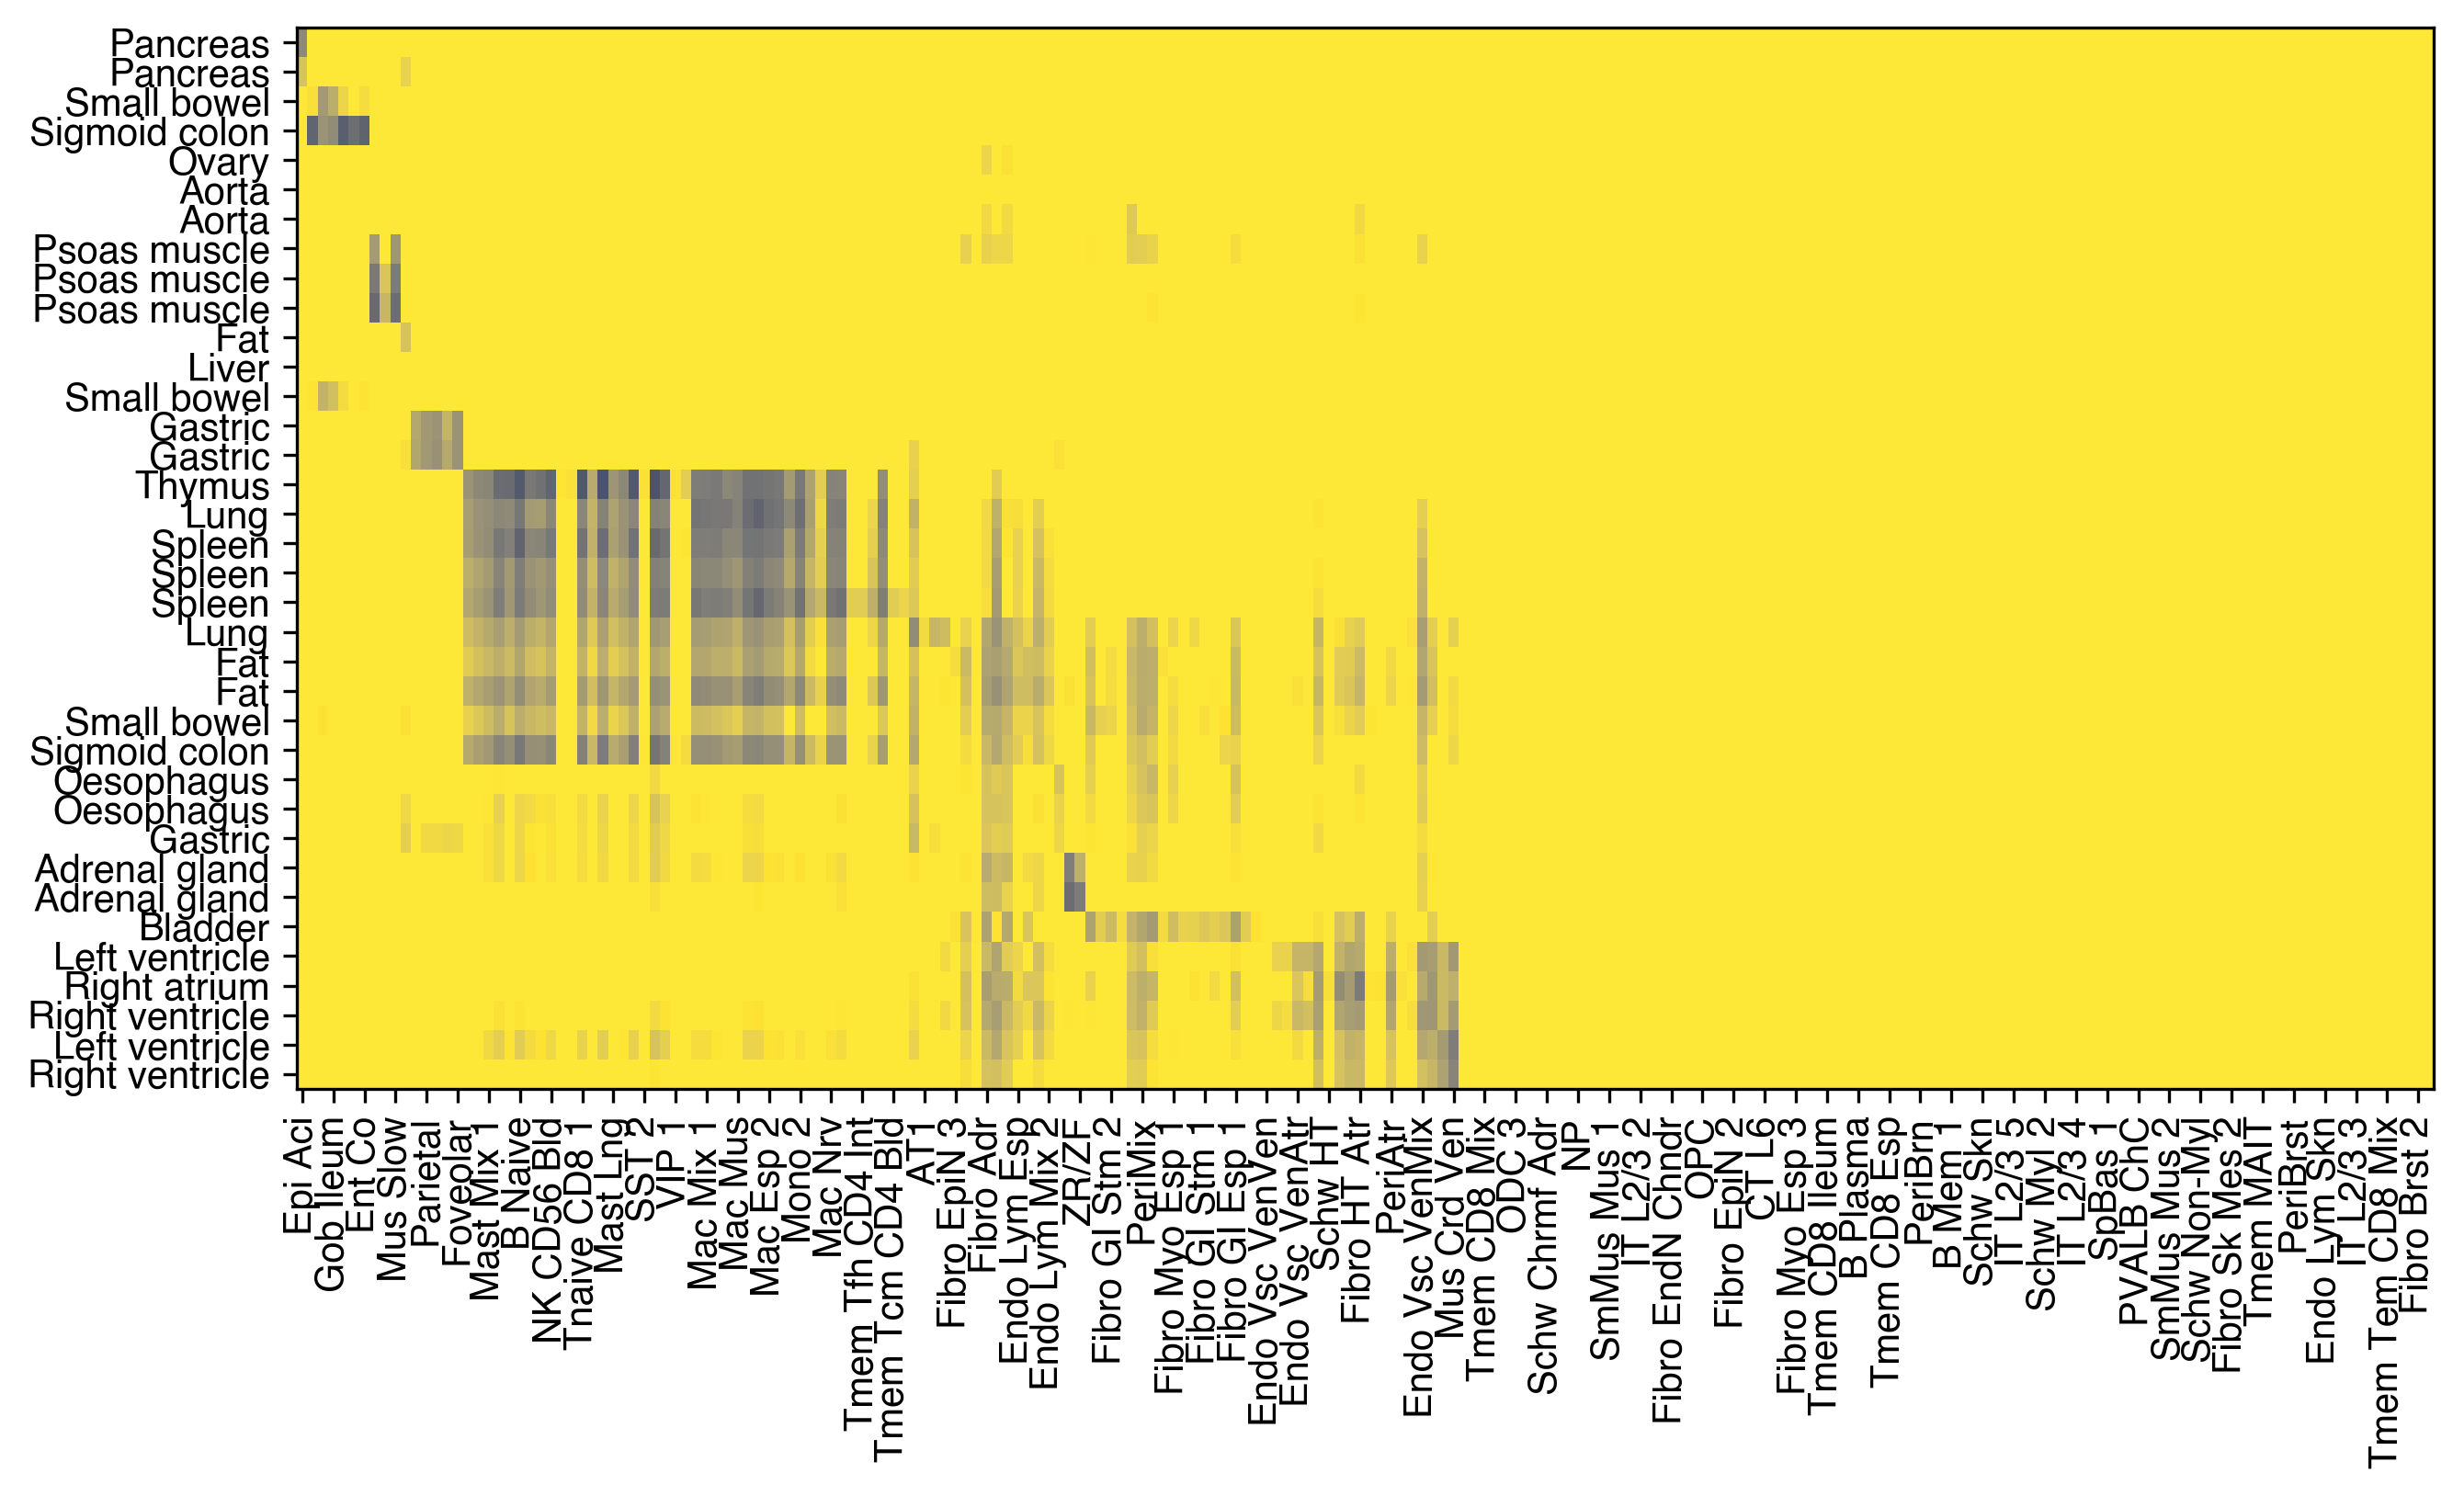

In [51]:
fig, ax = plt.subplots(figsize=(10,5), dpi=300)
ax.imshow(dist, cmap='cividis', aspect='auto', rasterized=True, vmin=0, vmax=0.01)
xticks = np.arange(0, dist.shape[1], 3)
ax.set_xticks(xticks)
ax.set_xticklabels(dist.columns[xticks], rotation=90)
yticks = np.arange(0, dist.shape[0], 1)
ax.set_yticks(yticks)
ax.set_yticklabels(dist.index.str.split('_').str[0].map(abbr_to_tissue), rotation=0)
fig.savefig(f'{outdir}cosine_subtype_Schultz.pdf', transparent=True)
